# Transient heat equation on a U-shaped domain — AlphaPINN spectral PINN

**PDE:**  $\partial_t u - \kappa\,\Delta u = 0$  (heat / diffusion)

**Domain:**  $[0,2]\times[0,2]$ minus a notch $(x\in(0.6,1.4),\; y>0.8)$,  time $t\in[0,T]$

**Initial condition:**  $u(x,y,0) = 0$

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot, held for all $t$
- $u = 0$ everywhere else on the boundary — cold, held for all $t$

**Method:**  **AlphaPINN — global spectral PINN without Method of Lines.**

Since the Laplace eigenvectors $\Phi$ are global spatial modes, the full
space-time solution can be written as:

$$u(x,t) = \Phi\,\alpha(t), \quad \alpha(t) = \text{FNN}(t) \in \mathbb{R}^K$$

The FNN takes only $t$ as input and outputs the spectral expansion coefficients.
Time derivatives follow by autodiff; no state, no rollout, no BPTT.

Physics is enforced through the Galerkin weak-form residual:

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0 \quad \forall\,\phi\in V_h, \; t\in[0,T]$$

The IC $u(\cdot,0)=0$ is added as a Dirichlet BC on the $t=0$ face of the domain.


## 1. Imports & environment

In [1]:
import pinns
import jax.numpy as jnp
import numpy as np

import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

X_MAX = 2
Y_MAX = 2
KAPPA = 1

## 2. Build the U-shaped triangulated mesh

<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

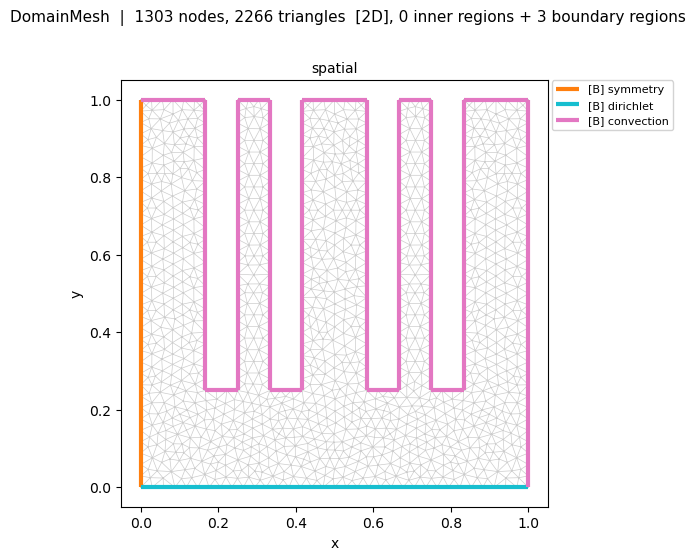

In [2]:
mesh = pinns.meshes.trident(mesh_size=0.03)

domain = pinns.domain.DomainMesh(mesh)

domain.add_boundary(lambda X: (X[:, 0] < 0.01), "symmetry")
domain.add_boundary(lambda X: (X[:, 1] < 0.01), "dirichlet")
domain.add_boundary(lambda X: ~((X[:, 0] < 0.01) | (X[:, 1] < 0.01)) | (X[:, 0] + X[:, 1] > 0.99), "convection")

domain.plot(boundary="custom", backend="matplotlib")

## 6. PDE problem & AlphaPINN network

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0$$

**Design:**  `ProblemWeak` is always defined **before** the network — it owns
the `output_transform` that enforces Dirichlet BCs and the IC ramp at every query point.
The network receives it as a constructor argument:

```python
problem = ProblemWeak(..., hard_constraints=["bc_name", ...])
net     = Network(domain, ..., output_transform=problem.output_transform)
```

This pattern is **identical** for continuous and state-integrator modes, and for
both `AlphaPINN` and `GNNMeshNetwork`.  In state-integrator mode the network also
clamps BC nodes internally before storing $u^{n+1}$ as the next $u^n$ (keeps rollout
stable), but that happens automatically — no extra argument required.

`AlphaPINN` is literally `LaplacianFeatures(domain, n_features) + FNN(hidden_dims)`:

| Component | Role |
|---|---|
| `LaplacianFeatures` | Maps `(x,y,t)` → `[Φ(x,y), t]` via barycentric interp of mesh eigenvectors |
| `FNN(hidden_dims)` | Standard MLP: `n_features` → `hidden_dims` → `n_outputs` |

No `n_time_steps`, no BPTT.  $\partial_t u$ comes from autodiff through the FNN w.r.t. the appended $t$ feature.


In [3]:
def volume_fn(x, y, params, phi, derivative=None):
    """Steady-state Poisson weak form: κ ∫ ∇u·∇φ dΩ = 0"""
    du_dx = derivative(y, x, 0, (0,))
    du_dy = derivative(y, x, 0, (1,))
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)

    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))
    grad_phi = jnp.stack([dphi_dx, dphi_dy], axis=-1)

    return jnp.sum(grad_u * grad_phi, axis=-1)

problem = pinns.ProblemWeak(domain=domain, output_names=["temperature"])

problem.add_inner(volume_fn, name="pde", region="inner")

problem.add_dirichlet(1.0, name="dirichlet",  region="dirichlet")
problem.add_neumann(0.0, name="symmetry",   region="symmetry")
def convection_fn(x, u, params, phi, derivative=None):
    # u has shape (N, n_out); extract scalar component 0 before multiplying with phi (N,)
    return -0.1 * u[..., 0] * phi
problem.add_neumann(convection_fn, name="convection", region="convection")

problem.add_fixed("kappa", KAPPA)


ProblemWeak(n_verts=1303, n_dofs=1303, n_faces=2266, n_free=1303, n_dirichlet=0, n_neumann_bcs=0, cubature_order=3, lagrange_order=1 (P1, 3 dofs/elem), basis='lagrange')

In [4]:
model = pinns.create_model(
    domain,
    output_dim=1,
    features=pinns.LaplacianFeatures(n_features=256),
    # core=pinns.PirateNet(128,3)
)

LaplacianFeatures: computing 256 Laplace eigenvectors for mesh with 1303 nodes … done.


## 7. Training

Standard PINN training — no curriculum, no BPTT.  The full space-time loss:

$$\mathcal{L}(\theta) = \|\mathcal{R}(u_\theta)\|^2 + \lambda_\text{BC}\|\text{BCs}\|^2 + \lambda_\text{IC}\|u_\theta(\cdot,0)\|^2$$

is minimised in one shot.


Starting training for 100000 epochs (JIT-compiled)...


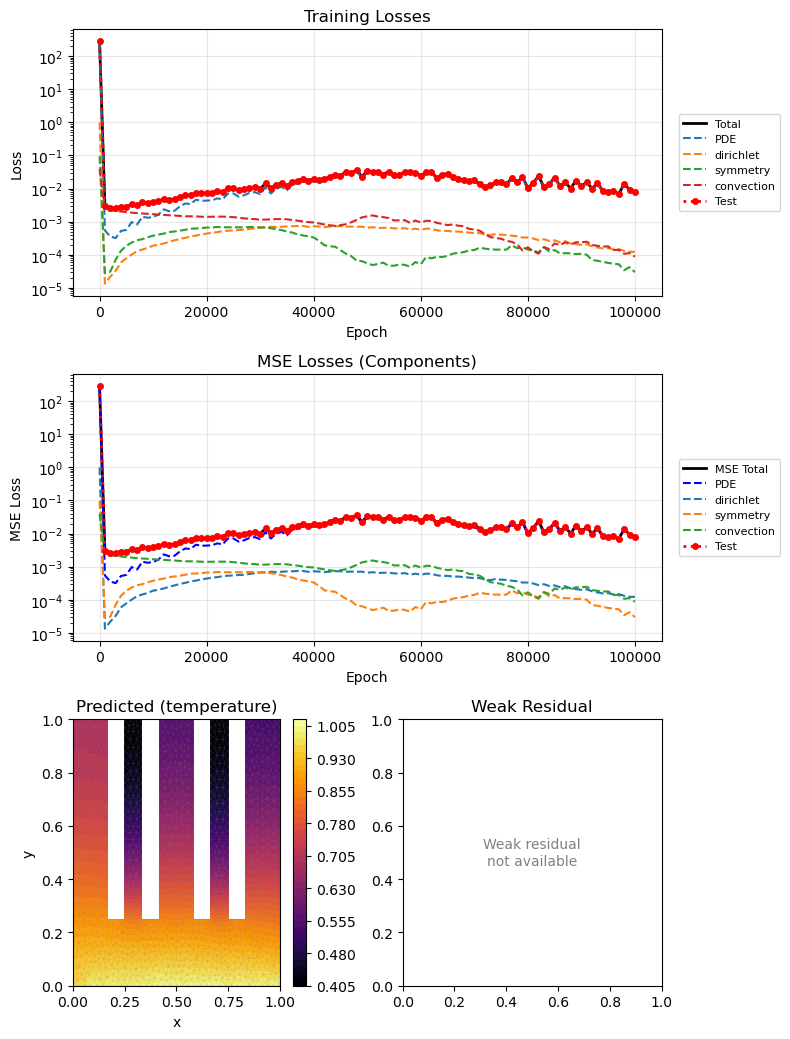

Epoch 0/100000 | Loss: 2.77e+02 | MSE Loss: 2.77e+02 | PDE: 2.76e+02 | BCs: [dirichlet: 9.89e-01, symmetry: 9.45e-02, convection: 3.90e-02] | Time: 0.0s | Test Loss: 2.77e+02
Epoch 1000/100000 | Loss: 2.92e-03 | MSE Loss: 2.92e-03 | PDE: 5.42e-04 | BCs: [dirichlet: 1.34e-05, symmetry: 2.76e-05, convection: 2.33e-03] | Time: 25.7s | Test Loss: 2.92e-03
Epoch 2000/100000 | Loss: 2.63e-03 | MSE Loss: 2.63e-03 | PDE: 3.55e-04 | BCs: [dirichlet: 2.18e-05, symmetry: 3.07e-05, convection: 2.20e-03] | Time: 28.0s | Test Loss: 2.63e-03
Epoch 3000/100000 | Loss: 2.56e-03 | MSE Loss: 2.56e-03 | PDE: 3.17e-04 | BCs: [dirichlet: 3.25e-05, symmetry: 7.04e-05, convection: 2.11e-03] | Time: 30.1s | Test Loss: 2.56e-03
Epoch 4000/100000 | Loss: 2.78e-03 | MSE Loss: 2.78e-03 | PDE: 5.21e-04 | BCs: [dirichlet: 5.87e-05, symmetry: 1.31e-04, convection: 2.02e-03] | Time: 32.2s | Test Loss: 2.79e-03
Epoch 5000/100000 | Loss: 2.84e-03 | MSE Loss: 2.84e-03 | PDE: 5.62e-04 | BCs: [dirichlet: 7.74e-05, symmetry

In [5]:
trainer = pinns.Trainer(problem, model)

trainer.compile(
    problem={
        "pde" :      {"train": 1000, "test": 50, "weight": 1.0},
        "dirichlet": {"train": 200,  "test": 10,  "weight": 1.0},
        "symmetry":  {"train": 200,  "test": 10,  "weight": 1.0},
        "convection":{"train": 1000,  "test": 10,  "weight": 1.0}
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[
        pinns.SchedulerLagrange(
            ["convection"]
        )
    ],
    epochs=100000,
    print_each=1000,
)

trainer.train()